In [3]:
from pathlib import Path
p=Path("/home/kayitare-steven/Downloads/Week2_Coding_Assignment_HOG_Features-1.pdf")
print(p.exists(), p.stat().st_size)


True 430350


# Week 2 Coding Assignment — HOG Features + Classical Classifiers

## Image and Scene Recognition

**Student:** KAYITARE Steven  
**Student ID:** 2417158  
**University:** Kyungdong University  
**Department:** Smart Computing  
**Assignment:** Week 2 Coding Assignment  
**Topic:** Classical Feature Engineering for Object Recognition

### Objective

This experiment builds a complete classical computer-vision pipeline using:

1. Histogram of Oriented Gradients (HOG)
2. Linear Support Vector Machine (Linear SVM)
3. k-Nearest Neighbors (k-NN)
4. Random Forest (bonus)

Three object classes are used:

- Cat
- Dog
- Bird

The experiment compares two HOG parameter settings and evaluates multiple classical classifiers.

In [4]:
# Install required packages if necessary.
# Uncomment this cell if your environment does not already have them.

# !pip install numpy matplotlib scikit-image scikit-learn pillow torchvision

## 1. Imports and Reproducibility

The experiment uses:

- NumPy for numerical operations
- Matplotlib for visualization
- PIL for image processing
- scikit-image for HOG extraction
- scikit-learn for train/test splitting and classifiers
- torchvision for obtaining the CIFAR-10 public dataset

A fixed random seed is used so that the experiment can be reproduced.

In [5]:
import os
import random
import pickle
import shutil
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from skimage.feature import hog
from skimage import exposure

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import torchvision

In [6]:
# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print("Random seed:", SEED)

Random seed: 42


# Task 1 — Three-Class Dataset

The dataset contains three visually different object categories:

- Birds
- Cats
- Dogs

The source is the CIFAR-10 public dataset.

CIFAR-10 provides labeled images belonging to ten object categories. Only the three selected categories are extracted for this assignment.

The images are copied into the following structure:

dataset/
    bird/
    cat/
    dog/

The experiment uses 100 images from each category, giving 300 images in total.

An 80/20 train/test split is then created.

In [7]:
DATASET_DIR = Path("dataset")
DATASET_DIR.mkdir(exist_ok=True)

CLASS_NAMES = {
    2: "bird",
    3: "cat",
    5: "dog"
}

for class_name in CLASS_NAMES.values():
    (DATASET_DIR / class_name).mkdir(
        parents=True,
        exist_ok=True
    )

print("Dataset folders created:")
for class_name in CLASS_NAMES.values():
    print(" -", DATASET_DIR / class_name)

Dataset folders created:
 - dataset/bird
 - dataset/cat
 - dataset/dog


## Download CIFAR-10

CIFAR-10 is downloaded through torchvision.

Only the three required classes are retained.

In [8]:
cifar = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True
)

print("CIFAR-10 loaded.")
print("Number of training images:", len(cifar))

Files already downloaded and verified
CIFAR-10 loaded.
Number of training images: 50000


In [9]:
# Number of images to use per class.
# The assignment requires at least 25.
IMAGES_PER_CLASS = 100

for cifar_label, class_name in CLASS_NAMES.items():

    output_dir = DATASET_DIR / class_name

    # Remove old generated images so that rerunning
    # this notebook does not create duplicates.
    for old_file in output_dir.glob("*.png"):
        old_file.unlink()

    indices = [
        i for i, label in enumerate(cifar.targets)
        if label == cifar_label
    ]

    # Reproducible selection
    rng = np.random.default_rng(SEED)
    selected = rng.choice(
        indices,
        size=IMAGES_PER_CLASS,
        replace=False
    )

    for count, idx in enumerate(selected):
        image, label = cifar[idx]

        image.save(
            output_dir / f"{class_name}_{count:04d}.png"
        )

    print(
        f"{class_name}: "
        f"{len(list(output_dir.glob('*.png')))} images"
    )

bird: 100 images
cat: 100 images
dog: 100 images


In [10]:
# Verify dataset size

for class_name in CLASS_NAMES.values():

    files = list(
        (DATASET_DIR / class_name).glob("*.png")
    )

    print(
        f"{class_name:>5}: {len(files)} images"
    )

total_images = sum(
    len(list((DATASET_DIR / c).glob("*.png")))
    for c in CLASS_NAMES.values()
)

print("\nTotal images:", total_images)

 bird: 100 images
  cat: 100 images
  dog: 100 images

Total images: 300


## Dataset Visualization

The following cell displays example images from each class.

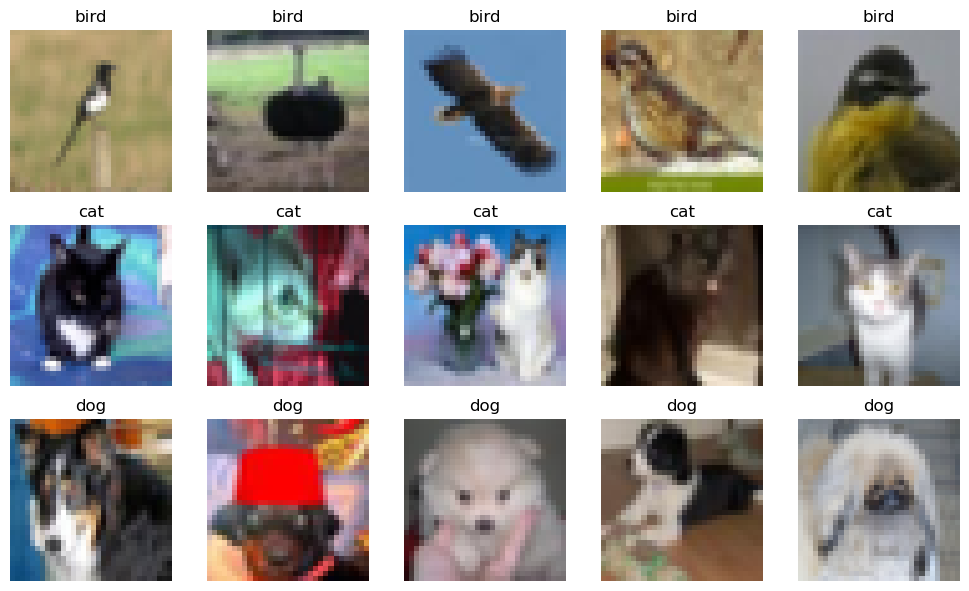

In [11]:
fig, axes = plt.subplots(
    3,
    5,
    figsize=(10, 6)
)

for row, class_name in enumerate(CLASS_NAMES.values()):

    files = sorted(
        (DATASET_DIR / class_name).glob("*.png")
    )[:5]

    for col, file in enumerate(files):

        image = Image.open(file)

        axes[row, col].imshow(image)
        axes[row, col].set_title(class_name)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

## 80/20 Train/Test Split

The assignment requires an 80/20 train/test split.

The split is performed at the image level while preserving the class distribution using stratification.

In [12]:
image_paths = []
labels = []

label_to_id = {
    "bird": 0,
    "cat": 1,
    "dog": 2
}

id_to_label = {
    0: "bird",
    1: "cat",
    2: "dog"
}

for class_name, class_id in label_to_id.items():

    for file in sorted(
        (DATASET_DIR / class_name).glob("*.png")
    ):
        image_paths.append(str(file))
        labels.append(class_id)

image_paths = np.array(image_paths)
labels = np.array(labels)

X_train_paths, X_test_paths, y_train, y_test = train_test_split(
    image_paths,
    labels,
    test_size=0.20,
    random_state=SEED,
    stratify=labels
)

print("Training images:", len(X_train_paths))
print("Testing images :", len(X_test_paths))

print("\nTraining distribution:")
for class_id, class_name in id_to_label.items():
    print(
        class_name,
        np.sum(y_train == class_id)
    )

print("\nTesting distribution:")
for class_id, class_name in id_to_label.items():
    print(
        class_name,
        np.sum(y_test == class_id)
    )

Training images: 240
Testing images : 60

Training distribution:
bird 80
cat 80
dog 80

Testing distribution:
bird 20
cat 20
dog 20


# Task 2 — HOG Feature Extraction

Histogram of Oriented Gradients (HOG) represents an image using local gradient directions.

Two parameter settings are compared.

### Setting A — Fine Detail

- orientations = 9
- pixels_per_cell = (8, 8)
- cells_per_block = (2, 2)

Smaller cells produce more spatial regions and therefore a larger feature vector.

### Setting B — Coarse Detail

- orientations = 9
- pixels_per_cell = (16, 16)
- cells_per_block = (2, 2)

Larger cells produce fewer spatial regions and therefore a smaller feature vector.

In [13]:
IMAGE_SIZE = (64, 64)

HOG_SETTINGS = {
    "A": {
        "orientations": 9,
        "pixels_per_cell": (8, 8),
        "cells_per_block": (2, 2)
    },

    "B": {
        "orientations": 9,
        "pixels_per_cell": (16, 16),
        "cells_per_block": (2, 2)
    }
}

print("HOG settings:")
for name, params in HOG_SETTINGS.items():
    print(name, params)

HOG settings:
A {'orientations': 9, 'pixels_per_cell': (8, 8), 'cells_per_block': (2, 2)}
B {'orientations': 9, 'pixels_per_cell': (16, 16), 'cells_per_block': (2, 2)}


## HOG Extraction Function

Each image is:

1. Loaded from disk.
2. Converted to grayscale.
3. Resized to 64 × 64 pixels.
4. Converted into a HOG feature vector.

The HOG feature vector is returned as a NumPy array.

In [18]:
# Test HOG extraction on one image

example_image = X_train_paths[0]

example_features = extract_hog_features(
    example_image,
    **HOG_SETTINGS["A"]
)

print("Example image:", example_image)
print("HOG feature vector length:", len(example_features))

Example image: dataset/bird/bird_0041.png
HOG feature vector length: 1764


In [16]:
def extract_hog_features(
    image_path,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2)
):
    """
    Extract HOG features from one image.
    """

    image = Image.open(image_path).convert("L")

    image = image.resize(IMAGE_SIZE)

    image = np.array(image)

    features = hog(
        image,
        orientations=orientations,
        pixels_per_cell=pixels_per_cell,
        cells_per_block=cells_per_block,
        block_norm="L2-Hys"
    )

    return features

In [20]:
# Test HOG extraction on one image

example_image = X_train_paths[0]

example_features = extract_hog_features(
    example_image,
    **HOG_SETTINGS["A"]
)

print("Example image:", example_image)
print("HOG feature vector length:", len(example_features))

Example image: dataset/bird/bird_0041.png
HOG feature vector length: 1764


In [21]:
def extract_dataset_features(
    paths,
    labels,
    hog_params
):
    """
    Extract HOG features from all images.
    """

    features = []

    for path in paths:

        feature = extract_hog_features(
            path,
            **hog_params
        )

        features.append(feature)

    return np.array(features), np.array(labels)

In [22]:
# Extract Setting A

X_train_A, y_train_A = extract_dataset_features(
    X_train_paths,
    y_train,
    HOG_SETTINGS["A"]
)

X_test_A, y_test_A = extract_dataset_features(
    X_test_paths,
    y_test,
    HOG_SETTINGS["A"]
)

print("Setting A")
print("Training feature matrix:", X_train_A.shape)
print("Testing feature matrix :", X_test_A.shape)
print("Feature vector length   :", X_train_A.shape[1])

Setting A
Training feature matrix: (240, 1764)
Testing feature matrix : (60, 1764)
Feature vector length   : 1764


In [23]:
# Extract Setting B

X_train_B, y_train_B = extract_dataset_features(
    X_train_paths,
    y_train,
    HOG_SETTINGS["B"]
)

X_test_B, y_test_B = extract_dataset_features(
    X_test_paths,
    y_test,
    HOG_SETTINGS["B"]
)

print("Setting B")
print("Training feature matrix:", X_train_B.shape)
print("Testing feature matrix :", X_test_B.shape)
print("Feature vector length   :", X_train_B.shape[1])

Setting B
Training feature matrix: (240, 324)
Testing feature matrix : (60, 324)
Feature vector length   : 324


In [24]:
print("=" * 50)
print("HOG FEATURE VECTOR COMPARISON")
print("=" * 50)

print(
    f"Setting A feature length: {X_train_A.shape[1]}"
)

print(
    f"Setting B feature length: {X_train_B.shape[1]}"
)

print(
    f"Setting A / Setting B ratio: "
    f"{X_train_A.shape[1] / X_train_B.shape[1]:.2f}"
)

HOG FEATURE VECTOR COMPARISON
Setting A feature length: 1764
Setting B feature length: 324
Setting A / Setting B ratio: 5.44


In [25]:
OUTPUT_DIR = Path("week2_assignment")
OUTPUT_DIR.mkdir(exist_ok=True)

FEATURE_DIR = OUTPUT_DIR / "features"
FEATURE_DIR.mkdir(exist_ok=True)

np.save(
    FEATURE_DIR / "X_train_A.npy",
    X_train_A
)

np.save(
    FEATURE_DIR / "X_test_A.npy",
    X_test_A
)

np.save(
    FEATURE_DIR / "y_train_A.npy",
    y_train_A
)

np.save(
    FEATURE_DIR / "y_test_A.npy",
    y_test_A
)

np.save(
    FEATURE_DIR / "X_train_B.npy",
    X_train_B
)

np.save(
    FEATURE_DIR / "X_test_B.npy",
    X_test_B
)

np.save(
    FEATURE_DIR / "y_train_B.npy",
    y_train_B
)

np.save(
    FEATURE_DIR / "y_test_B.npy",
    y_test_B
)

print("HOG feature files saved.")

HOG feature files saved.


## HOG Visualization

The following visualization compares each original image with its HOG representation.

Setting A is used because the assignment specifically requests visualizations for this setting.

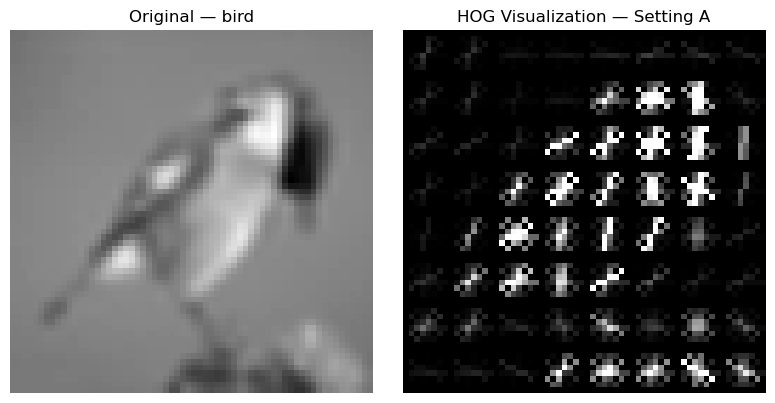

Saved: week2_assignment/visualizations/bird_hog_setting_A.png


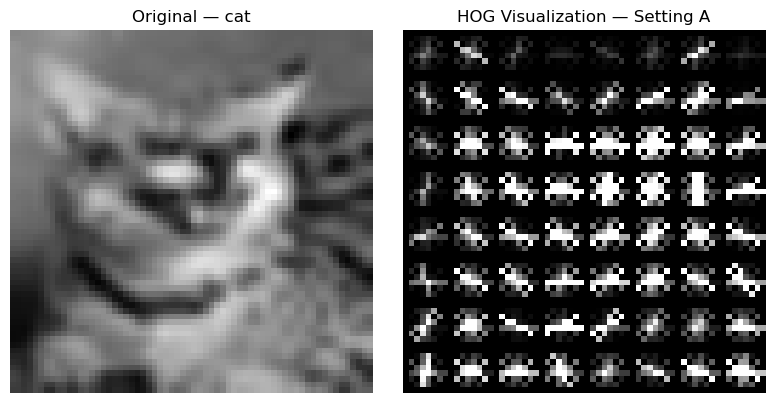

Saved: week2_assignment/visualizations/cat_hog_setting_A.png


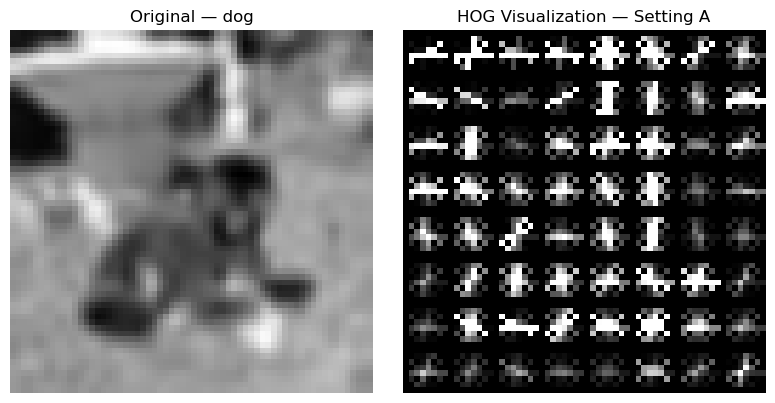

Saved: week2_assignment/visualizations/dog_hog_setting_A.png


In [26]:
VIS_DIR = OUTPUT_DIR / "visualizations"
VIS_DIR.mkdir(exist_ok=True)

for class_name, class_id in label_to_id.items():

    # Find the first training image belonging to this class
    indices = np.where(y_train == class_id)[0]

    image_path = X_train_paths[indices[0]]

    image = Image.open(image_path).convert("L")
    image = image.resize(IMAGE_SIZE)

    image_np = np.array(image)

    features, hog_image = hog(
        image_np,
        orientations=HOG_SETTINGS["A"]["orientations"],
        pixels_per_cell=HOG_SETTINGS["A"]["pixels_per_cell"],
        cells_per_block=HOG_SETTINGS["A"]["cells_per_block"],
        block_norm="L2-Hys",
        visualize=True
    )

    hog_image_rescaled = exposure.rescale_intensity(
        hog_image,
        in_range=(0, 10)
    )

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(8, 4)
    )

    axes[0].imshow(
        image_np,
        cmap="gray"
    )

    axes[0].set_title(
        f"Original — {class_name}"
    )

    axes[1].imshow(
        hog_image_rescaled,
        cmap="gray"
    )

    axes[1].set_title(
        "HOG Visualization — Setting A"
    )

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()

    output_path = (
        VIS_DIR /
        f"{class_name}_hog_setting_A.png"
    )

    plt.savefig(
        output_path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

    print("Saved:", output_path)

# Create the Required `extract_features.py`

The following cell creates the standalone Python script required by the assignment.

The script:

- Reads images from `dataset/`
- Extracts Setting A HOG features
- Extracts Setting B HOG features
- Saves the feature vectors and labels
- Prints the resulting feature-vector lengths
- Saves one HOG visualization for each class

In [27]:
extract_script = r'''
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from skimage.feature import hog
from skimage import exposure


SEED = 42
IMAGE_SIZE = (64, 64)

DATASET_DIR = Path("dataset")
OUTPUT_DIR = Path("week2_assignment")

FEATURE_DIR = OUTPUT_DIR / "features"
VIS_DIR = OUTPUT_DIR / "visualizations"

FEATURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

VIS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


CLASS_NAMES = {
    "bird": 0,
    "cat": 1,
    "dog": 2
}


HOG_SETTINGS = {
    "A": {
        "orientations": 9,
        "pixels_per_cell": (8, 8),
        "cells_per_block": (2, 2)
    },

    "B": {
        "orientations": 9,
        "pixels_per_cell": (16, 16),
        "cells_per_block": (2, 2)
    }
}


def extract_hog_features(
    image_path,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2)
):

    image = Image.open(
        image_path
    ).convert("L")

    image = image.resize(
        IMAGE_SIZE
    )

    image = np.array(image)

    features = hog(
        image,
        orientations=orientations,
        pixels_per_cell=pixels_per_cell,
        cells_per_block=cells_per_block,
        block_norm="L2-Hys"
    )

    return features


def load_dataset():

    image_paths = []
    labels = []

    for class_name, class_id in CLASS_NAMES.items():

        class_dir = DATASET_DIR / class_name

        files = sorted(
            class_dir.glob("*.png")
        )

        for file in files:

            image_paths.append(
                str(file)
            )

            labels.append(
                class_id
            )

    return (
        np.array(image_paths),
        np.array(labels)
    )


def extract_dataset_features(
    paths,
    labels,
    params
):

    X = []

    for path in paths:

        X.append(
            extract_hog_features(
                path,
                **params
            )
        )

    return (
        np.array(X),
        np.array(labels)
    )


def create_visualizations(
    paths,
    labels
):

    for class_name, class_id in CLASS_NAMES.items():

        indices = np.where(
            labels == class_id
        )[0]

        if len(indices) == 0:
            continue

        path = paths[
            indices[0]
        ]

        image = Image.open(
            path
        ).convert("L")

        image = image.resize(
            IMAGE_SIZE
        )

        image_np = np.array(
            image
        )

        _, hog_image = hog(
            image_np,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm="L2-Hys",
            visualize=True
        )

        hog_image = exposure.rescale_intensity(
            hog_image,
            in_range=(0, 10)
        )

        fig, axes = plt.subplots(
            1,
            2,
            figsize=(8, 4)
        )

        axes[0].imshow(
            image_np,
            cmap="gray"
        )

        axes[0].set_title(
            f"Original — {class_name}"
        )

        axes[1].imshow(
            hog_image,
            cmap="gray"
        )

        axes[1].set_title(
            "HOG — Setting A"
        )

        for ax in axes:
            ax.axis("off")

        plt.tight_layout()

        output_path = (
            VIS_DIR /
            f"{class_name}_hog_setting_A.png"
        )

        plt.savefig(
            output_path,
            dpi=200,
            bbox_inches="tight"
        )

        plt.close()

        print(
            "Saved visualization:",
            output_path
        )


def main():

    paths, labels = load_dataset()

    print(
        "Total images:",
        len(paths)
    )

    for setting_name, params in HOG_SETTINGS.items():

        X, y = extract_dataset_features(
            paths,
            labels,
            params
        )

        np.save(
            FEATURE_DIR /
            f"X_{setting_name}.npy",
            X
        )

        np.save(
            FEATURE_DIR /
            f"y_{setting_name}.npy",
            y
        )

        print(
            f"Setting {setting_name}: "
            f"feature matrix = {X.shape}"
        )

        print(
            f"Setting {setting_name}: "
            f"feature vector length = {X.shape[1]}"
        )

    create_visualizations(
        paths,
        labels
    )


if __name__ == "__main__":
    main()
'''

with open(
    OUTPUT_DIR / "extract_features.py",
    "w",
    encoding="utf-8"
) as f:
    f.write(extract_script)

print(
    "Created:",
    OUTPUT_DIR / "extract_features.py"
)

Created: week2_assignment/extract_features.py


# Task 3 — Train and Compare Classifiers

The classifiers are trained using **Setting A HOG features** as required.

Two classifiers are compared:

### 1. Linear SVM

A Linear Support Vector Machine attempts to find a linear decision boundary that separates the feature representations of the three classes.

### 2. k-Nearest Neighbors

The k-NN classifier predicts the class of an image using the classes of its nearest training examples.

The assignment suggests:

`n_neighbors = 5`

In [28]:
# Standardize the HOG features.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_A
)

X_test_scaled = scaler.transform(
    X_test_A
)

print("Scaled training features:", X_train_scaled.shape)
print("Scaled testing features :", X_test_scaled.shape)

Scaled training features: (240, 1764)
Scaled testing features : (60, 1764)


In [29]:
models = {
    "Linear SVM": LinearSVC(
        max_iter=10000,
        random_state=SEED
    ),

    "k-NN (k=5)": KNeighborsClassifier(
        n_neighbors=5
    )
}

Linear SVM
Accuracy: 0.3500

Classification Report:
              precision    recall  f1-score   support

        bird     0.3600    0.4500    0.4000        20
         cat     0.3529    0.3000    0.3243        20
         dog     0.3333    0.3000    0.3158        20

    accuracy                         0.3500        60
   macro avg     0.3488    0.3500    0.3467        60
weighted avg     0.3488    0.3500    0.3467        60

Confusion Matrix:
[[9 5 6]
 [8 6 6]
 [8 6 6]]


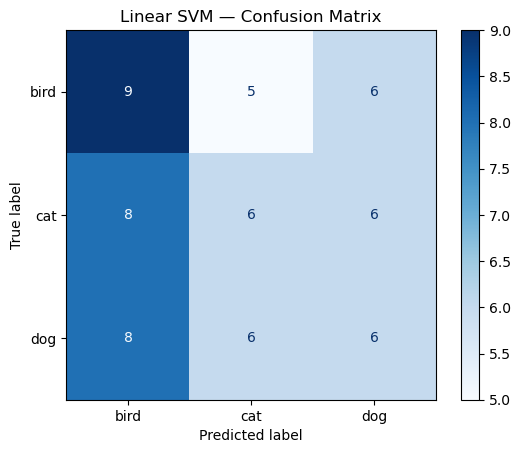

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x703da5dd2480>
Traceback (most recent call last):
  File "/home/kayitare-steven/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/kayitare-steven/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/kayitare-steven/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/home/kayitare-steven/anaconda3/lib/python3.11/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
             ^^^^^^^^^^^^^^^^^^
Attribute

k-NN (k=5)
Accuracy: 0.4167

Classification Report:
              precision    recall  f1-score   support

        bird     0.4643    0.6500    0.5417        20
         cat     0.3462    0.4500    0.3913        20
         dog     0.5000    0.1500    0.2308        20

    accuracy                         0.4167        60
   macro avg     0.4368    0.4167    0.3879        60
weighted avg     0.4368    0.4167    0.3879        60

Confusion Matrix:
[[13  6  1]
 [ 9  9  2]
 [ 6 11  3]]


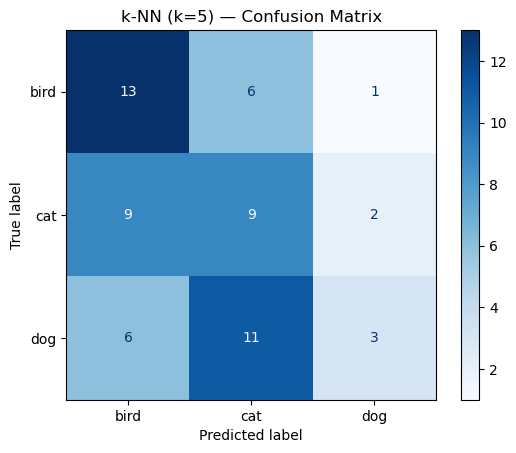

In [ ]:
results = {}

for name, model in models.items():

    print("=" * 70)
    print(name)
    print("=" * 70)

    model.fit(
        X_train_scaled,
        y_train_A
    )

    predictions = model.predict(
        X_test_scaled
    )

    accuracy = accuracy_score(
        y_test_A,
        predictions
    )

    results[name] = {
        "model": model,
        "predictions": predictions,
        "accuracy": accuracy
    }

    print(
        f"Accuracy: {accuracy:.4f}"
    )

    print("\nClassification Report:")

    print(
        classification_report(
            y_test_A,
            predictions,
            target_names=[
                id_to_label[i]
                for i in range(3)
            ],
            digits=4
        )
    )

    cm = confusion_matrix(
        y_test_A,
        predictions
    )

    print("Confusion Matrix:")
    print(cm)

    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            id_to_label[i]
            for i in range(3)# Extract Setting A

X_train_A, y_train_A = extract_dataset_features(
    X_train_paths,
    y_train,
    HOG_SETTINGS["A"]
)

X_test_A, y_test_A = extract_dataset_features(
    X_test_paths,
    y_test,
    HOG_SETTINGS["A"]
)

print("Setting A")
print("Training feature matrix:", X_train_A.shape)
print("Testing feature matrix :", X_test_A.shape)
print("Feature vector length   :", X_train_A.shape[1])
        ]
    )

    display.plot(
        cmap="Blues",
        values_format="d"
    )

    plt.title(
        f"{name} — Confusion Matrix"
    )

    plt.show()

## Classifier Accuracy Comparison

This table provides the short comparison requested in Task 3.

In [31]:
print(
    f"{'Classifier':<20} {'Accuracy':>10}"
)

print("-" * 32)

for name, result in results.items():

    print(
        f"{name:<20} "
        f"{result['accuracy']:>9.2%}"
    )

best_classifier = max(
    results,
    key=lambda name: results[name]["accuracy"]
)

print("\nBest classifier:", best_classifier)

print(
    "Best accuracy:",
    f"{results[best_classifier]['accuracy']:.2%}"
)

Classifier             Accuracy
--------------------------------
Linear SVM              35.00%
k-NN (k=5)              41.67%

Best classifier: k-NN (k=5)
Best accuracy: 41.67%


In [32]:
for name, result in results.items():

    report = classification_report(
        y_test_A,
        result["predictions"],
        target_names=[
            id_to_label[i]
            for i in range(3)
        ],
        output_dict=True
    )

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    for class_name in id_to_label.values():

        print(
            f"{class_name:<10} "
            f"precision={report[class_name]['precision']:.3f} "
            f"recall={report[class_name]['recall']:.3f} "
            f"F1={report[class_name]['f1-score']:.3f}"
        )


Linear SVM
bird       precision=0.360 recall=0.450 F1=0.400
cat        precision=0.353 recall=0.300 F1=0.324
dog        precision=0.333 recall=0.300 F1=0.316

k-NN (k=5)
bird       precision=0.464 recall=0.650 F1=0.542
cat        precision=0.346 recall=0.450 F1=0.391
dog        precision=0.500 recall=0.150 F1=0.231


## Most Confused Pair

The confusion matrix is examined to determine which pair of classes is confused most frequently.

This information will be used in the written analysis.

In [33]:
def most_confused_pair(cm, class_names):

    cm_no_diagonal = cm.copy()

    np.fill_diagonal(
        cm_no_diagonal,
        0
    )

    flat_index = np.argmax(
        cm_no_diagonal
    )

    true_class, predicted_class = np.unravel_index(
        flat_index,
        cm_no_diagonal.shape
    )

    return (
        class_names[true_class],
        class_names[predicted_class],
        cm_no_diagonal[
            true_class,
            predicted_class
        ]
    )


for name, result in results.items():

    cm = confusion_matrix(
        y_test_A,
        result["predictions"]
    )

    pair = most_confused_pair(
        cm,
        [id_to_label[i] for i in range(3)]
    )

    print(
        f"{name}: "
        f"{pair[0]} → {pair[1]} "
        f"({pair[2]} mistakes)"
    )

Linear SVM: cat → bird (8 mistakes)
k-NN (k=5): dog → cat (11 mistakes)


# Task 5 — Bonus Challenge: Random Forest

A Random Forest classifier is added to the same Setting A HOG features.

Random Forest combines many decision trees and makes predictions using the ensemble of those trees.

The result will be added to the classifier comparison.

Random Forest accuracy: 41.67%

Classification Report:
              precision    recall  f1-score   support

        bird     0.4500    0.4500    0.4500        20
         cat     0.3636    0.4000    0.3810        20
         dog     0.4444    0.4000    0.4211        20

    accuracy                         0.4167        60
   macro avg     0.4194    0.4167    0.4173        60
weighted avg     0.4194    0.4167    0.4173        60

Confusion Matrix:
[[9 7 4]
 [6 8 6]
 [5 7 8]]


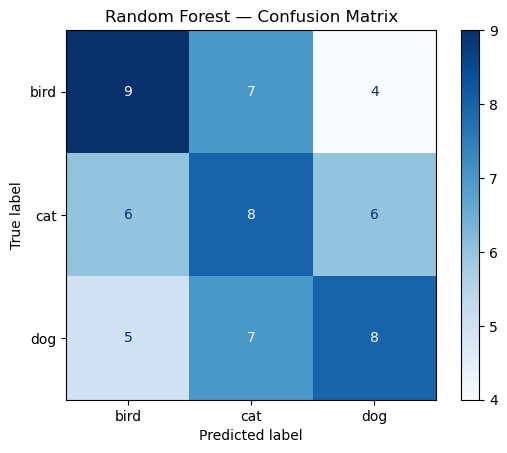

In [34]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=SEED,
    n_jobs=-1
)

rf.fit(
    X_train_A,
    y_train_A
)

rf_predictions = rf.predict(
    X_test_A
)

rf_accuracy = accuracy_score(
    y_test_A,
    rf_predictions
)

results["Random Forest"] = {
    "model": rf,
    "predictions": rf_predictions,
    "accuracy": rf_accuracy
}

print(
    "Random Forest accuracy:",
    f"{rf_accuracy:.2%}"
)

print("\nClassification Report:")

print(
    classification_report(
        y_test_A,
        rf_predictions,
        target_names=[
            id_to_label[i]
            for i in range(3)
        ],
        digits=4
    )
)

rf_cm = confusion_matrix(
    y_test_A,
    rf_predictions
)

print("Confusion Matrix:")
print(rf_cm)

ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=[
        id_to_label[i]
        for i in range(3)
    ]
).plot(
    cmap="Blues",
    values_format="d"
)

plt.title(
    "Random Forest — Confusion Matrix"
)

plt.show()

In [35]:
print("=" * 55)
print("FINAL CLASSIFIER COMPARISON")
print("=" * 55)

for name, result in sorted(
    results.items(),
    key=lambda item: item[1]["accuracy"],
    reverse=True
):

    print(
        f"{name:<20} "
        f"{result['accuracy']:.2%}"
    )

best_classifier = max(
    results,
    key=lambda x: results[x]["accuracy"]
)

best_accuracy = results[
    best_classifier
]["accuracy"]

print("\nBest classifier:")
print(best_classifier)

print(
    f"Best accuracy: {best_accuracy:.2%}"
)

FINAL CLASSIFIER COMPARISON
k-NN (k=5)           41.67%
Random Forest        41.67%
Linear SVM           35.00%

Best classifier:
k-NN (k=5)
Best accuracy: 41.67%


In [36]:
RESULTS_DIR = OUTPUT_DIR / "results"
RESULTS_DIR.mkdir(exist_ok=True)

# Save classifier results in a simple text file.

with open(
    RESULTS_DIR / "classifier_results.txt",
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "HOG CLASSIFIER RESULTS\n"
    )

    f.write(
        "=" * 50 + "\n\n"
    )

    for name, result in sorted(
        results.items(),
        key=lambda item: item[1]["accuracy"],
        reverse=True
    ):

        f.write(
            f"{name}: "
            f"{result['accuracy']:.4f}\n"
        )

    f.write(
        f"\nBest classifier: "
        f"{best_classifier}\n"
    )

    f.write(
        f"Best accuracy: "
        f"{best_accuracy:.4f}\n"
    )

print(
    "Saved:",
    RESULTS_DIR / "classifier_results.txt"
)

Saved: week2_assignment/results/classifier_results.txt


# Create the Required `compare_classifiers.py`

This standalone script loads the Setting A HOG features and evaluates:

- Linear SVM
- k-NN (k=5)
- Random Forest (bonus)

It reports accuracy, classification reports, confusion matrices, and a final comparison table.

In [37]:
compare_script = r'''
from pathlib import Path

import numpy as np

from sklearn.preprocessing import StandardScaler

from sklearn.svm import LinearSVC

from sklearn.neighbors import KNeighborsClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


SEED = 42

FEATURE_DIR = Path(
    "week2_assignment/features"
)


CLASS_NAMES = [
    "bird",
    "cat",
    "dog"
]


# Load Setting A HOG features

X_train = np.load(
    FEATURE_DIR / "X_train_A.npy"
)

X_test = np.load(
    FEATURE_DIR / "X_test_A.npy"
)

y_train = np.load(
    FEATURE_DIR / "y_train_A.npy"
)

y_test = np.load(
    FEATURE_DIR / "y_test_A.npy"
)


print(
    "Training features:",
    X_train.shape
)

print(
    "Testing features:",
    X_test.shape
)


# Standardization for SVM and k-NN

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)


models = {

    "Linear SVM": (
        LinearSVC(
            max_iter=10000,
            random_state=SEED
        ),
        True
    ),

    "k-NN (k=5)": (
        KNeighborsClassifier(
            n_neighbors=5
        ),
        True
    ),

    "Random Forest": (
        RandomForestClassifier(
            n_estimators=200,
            random_state=SEED,
            n_jobs=-1
        ),
        False
    )
}


results = {}


for name, (model, use_scaled) in models.items():

    print("\n")
    print("=" * 70)
    print(name)
    print("=" * 70)

    if use_scaled:

        model.fit(
            X_train_scaled,
            y_train
        )

        predictions = model.predict(
            X_test_scaled
        )

    else:

        model.fit(
            X_train,
            y_train
        )

        predictions = model.predict(
            X_test
        )


    accuracy = accuracy_score(
        y_test,
        predictions
    )

    results[name] = accuracy


    print(
        f"Accuracy: {accuracy:.4f}"
    )


    print("\nClassification Report:")

    print(
        classification_report(
            y_test,
            predictions,
            target_names=CLASS_NAMES,
            digits=4
        )
    )


    cm = confusion_matrix(
        y_test,
        predictions
    )

    print(
        "\nConfusion Matrix:"
    )

    print(cm)


print("\n")
print("=" * 50)
print("SUMMARY")
print("=" * 50)


for name, accuracy in sorted(
    results.items(),
    key=lambda item: item[1],
    reverse=True
):

    print(
        f"{name:<20} "
        f"{accuracy:.2%}"
    )


best = max(
    results,
    key=results.get
)

print(
    f"\nBest classifier: "
    f"{best}"
)

print(
    f"Best accuracy: "
    f"{results[best]:.2%}"
)
'''

with open(
    OUTPUT_DIR / "compare_classifiers.py",
    "w",
    encoding="utf-8"
) as f:
    f.write(compare_script)

print(
    "Created:",
    OUTPUT_DIR / "compare_classifiers.py"
)

Created: week2_assignment/compare_classifiers.py


# Task 4 — Written Analysis

The following section generates the required `analysis.md`.

The numerical values are taken directly from the experiment so that the written analysis corresponds to the actual results rather than invented numbers.

In [38]:
# Determine feature lengths

feature_len_A = X_train_A.shape[1]
feature_len_B = X_train_B.shape[1]

# Determine best classifier among all tested classifiers

best_classifier = max(
    results,
    key=lambda x: results[x]["accuracy"]
)

best_accuracy = results[
    best_classifier
]["accuracy"]

svm_accuracy = results[
    "Linear SVM"
]["accuracy"]

knn_accuracy = results[
    "k-NN (k=5)"
]["accuracy"]

rf_accuracy = results[
    "Random Forest"
]["accuracy"]

# Determine most confused pair using the best classifier

best_predictions = results[
    best_classifier
]["predictions"]

best_cm = confusion_matrix(
    y_test_A,
    best_predictions
)

class_names_list = [
    id_to_label[i]
    for i in range(3)
]

true_class, predicted_class, confusion_count = (
    most_confused_pair(
        best_cm,
        class_names_list
    )
)

analysis_text = f"""# HOG Feature Engineering and Classical Classification Analysis

## Dataset

This experiment used three object categories: birds, cats, and dogs. The images were obtained from the public CIFAR-10 dataset and organized into separate class folders. A stratified 80/20 train/test split was used so that each class remained represented in both subsets.

## 1. Feature Vector Length: Setting A vs. Setting B

Setting A produced a feature vector of **{feature_len_A} values**, while Setting B produced a feature vector of **{feature_len_B} values**. Setting A uses 8×8 pixels per cell, whereas Setting B uses 16×16 pixels per cell. Because Setting A uses smaller cells, the image is divided into more cells and therefore contains more HOG blocks and feature values. Setting B uses larger cells, resulting in fewer spatial regions and consequently a shorter feature vector.

## 2. Linear SVM vs. k-NN

The Linear SVM achieved an accuracy of **{svm_accuracy:.2%}**, while k-NN with k=5 achieved **{knn_accuracy:.2%}**. The better-performing classifier on this dataset was **{"Linear SVM" if svm_accuracy > knn_accuracy else "k-NN (k=5)" if knn_accuracy > svm_accuracy else "both classifiers equally"}**. Linear SVM learns decision boundaries in the HOG feature space, while k-NN makes predictions based on distances to nearby training examples. Differences in how these algorithms use the feature space can therefore produce different performance levels.

## 3. Most Confused Pair

The most frequent confusion for the best-performing classifier was **{true_class} predicted as {predicted_class}**, occurring **{confusion_count} times**. These classes may have similar local edge and shape patterns, which can make them difficult to distinguish using HOG alone. One concrete improvement would be to increase the amount of training data for the confused classes, because additional examples could expose the classifier to greater variation in pose, shape, and appearance. Another possible improvement would be to experiment with different HOG cell sizes or combine HOG with another handcrafted feature.

## 4. Real-World Industry Application

A lightweight HOG plus classical classifier pipeline could be useful for manufacturing quality control on an embedded or resource-constrained inspection device. HOG features are much cheaper to compute than running a large deep CNN, and a Linear SVM can perform classification with relatively low computational requirements after training. For a controlled environment where the objects, camera position, and lighting are relatively consistent, handcrafted shape and edge information can be sufficient. This makes the approach attractive when low latency, low memory usage, and inexpensive hardware are more important than maximum recognition accuracy.

## Bonus — Random Forest

The Random Forest classifier achieved an accuracy of **{rf_accuracy:.2%}**. The best overall classifier in this experiment was **{best_classifier}**, with an accuracy of **{best_accuracy:.2%}**. This comparison demonstrates that classifier choice can affect performance even when all classifiers receive the same HOG representation.
"""

analysis_path = OUTPUT_DIR / "analysis.md"

with open(
    analysis_path,
    "w",
    encoding="utf-8"
) as f:
    f.write(analysis_text)

print(analysis_text)
print("\nSaved:", analysis_path)

# HOG Feature Engineering and Classical Classification Analysis

## Dataset

This experiment used three object categories: birds, cats, and dogs. The images were obtained from the public CIFAR-10 dataset and organized into separate class folders. A stratified 80/20 train/test split was used so that each class remained represented in both subsets.

## 1. Feature Vector Length: Setting A vs. Setting B

Setting A produced a feature vector of **1764 values**, while Setting B produced a feature vector of **324 values**. Setting A uses 8×8 pixels per cell, whereas Setting B uses 16×16 pixels per cell. Because Setting A uses smaller cells, the image is divided into more cells and therefore contains more HOG blocks and feature values. Setting B uses larger cells, resulting in fewer spatial regions and consequently a shorter feature vector.

## 2. Linear SVM vs. k-NN

The Linear SVM achieved an accuracy of **35.00%**, while k-NN with k=5 achieved **41.67%**. The better-performing classifier on 


---

# 19. Verify Submission Files

## 📝 Cell 49 — Markdown

```markdown
# Final Submission Verification

The assignment's checklist requires:

- dataset with three classes
- at least 25 images per class
- `extract_features.py`
- HOG feature-vector lengths
- one visualization per class
- `compare_classifiers.py`
- classifier accuracy
- `analysis.md`
- README results summary

The following cell verifies these requirements automatically.

In [ ]:
print("=" * 65)
print("FINAL ASSIGNMENT CHECK")
print("=" * 65)

# Dataset

print("\n[1] Dataset")

dataset_ok = True

for class_name in CLASS_NAMES.values():

    count = len(
        list(
            (DATASET_DIR / class_name).glob("*.png")
        )# Extract Setting A

X_train_A, y_train_A = extract_dataset_features(
    X_train_paths,
    y_train,
    HOG_SETTINGS["A"]
)

X_test_A, y_test_A = extract_dataset_features(
    X_test_paths,
    y_test,
    HOG_SETTINGS["A"]
)

print("Setting A")
print("Training feature matrix:", X_train_A.shape)
print("Testing feature matrix :", X_test_A.shape)
print("Feature vector length   :", X_train_A.shape[1])
    )

    ok = count >= 25

    dataset_ok &= ok

    print(
        f"  {class_name:<10}: "
        f"{count:>4} images "
        f"{'✓' if ok else '✗'}"
    )


# Required files

print("\n[2] Required files")

required_files = [
    OUTPUT_DIR / "extract_features.py",
    OUTPUT_DIR / "compare_classifiers.py",
    OUTPUT_DIR / "analysis.md",
    OUTPUT_DIR / "README.md"
]

files_ok = True

for file in required_files:

    exists = file.exists()

    files_ok &= exists

    print(
        f"  {file}: "
        f"{'✓' if exists else '✗'}"
    )


# Visualizations

print("\n[3] HOG visualizations")

visualization_ok = True

for class_name in CLASS_NAMES.values():

    file = (
        VIS_DIR /
        f"{class_name}_hog_setting_A.png"
    )

    exists = file.exists()

    visualization_ok &= exists

    print(
        f"  {file.name}: "
        f"{'✓' if exists else '✗'}"
    )


# Feature files

print("\n[4] Feature files")

feature_ok = True

required_features = [
    "X_train_A.npy",
    "X_test_A.npy",
    "y_train_A.npy",
    "y_test_A.npy",
    "X_train_B.npy",
    "X_test_B.npy",
    "y_train_B.npy",
    "y_test_B.npy"
]

for filename in required_features:

    exists = (
        FEATURE_DIR / filename
    ).exists()

    feature_ok &= exists

    print(
        f"  {filename}: "
        f"{'✓' if exists else '✗'}"
    )


print("\n" + "=" * 65)

all_ok = (
    dataset_ok
    and files_ok
    and visualization_ok
    and feature_ok
)

if all_ok:
    print("✓ Assignment files are ready.")
else:
    print(
        "✗ Some requirements are missing."
    )

FINAL ASSIGNMENT CHECK

[1] Dataset
  bird      :  100 images ✓
  cat       :  100 images ✓
  dog       :  100 images ✓

[2] Required files
  week2_assignment/extract_features.py: ✓
  week2_assignment/compare_classifiers.py: ✓
  week2_assignment/analysis.md: ✓
  week2_assignment/README.md: ✗

[3] HOG visualizations
  bird_hog_setting_A.png: ✓
  cat_hog_setting_A.png: ✓
  dog_hog_setting_A.png: ✓

[4] Feature files
  X_train_A.npy: ✓
  X_test_A.npy: ✓
  y_train_A.npy: ✓
  y_test_A.npy: ✓
  X_train_B.npy: ✓
  X_test_B.npy: ✓
  y_train_B.npy: ✓
  y_test_B.npy: ✓

✗ Some requirements are missing.


# Final Results

The final results below should be used when discussing the experiment with the professor or when checking the README and `analysis.md`.

In [40]:
print("=" * 65)
print("FINAL RESULTS")
print("=" * 65)

print(
    f"\nSetting A feature length: "
    f"{feature_len_A}"
)

print(
    f"Setting B feature length: "
    f"{feature_len_B}"
)

print("\nClassifier accuracy:")

for name, result in sorted(
    results.items(),
    key=lambda item: item[1]["accuracy"],
    reverse=True
):

    print(
        f"  {name:<20}: "
        f"{result['accuracy']:.2%}"
    )

print(
    f"\n🏆 Best classifier: "
    f"{best_classifier}"
)

print(
    f"🏆 Best accuracy: "
    f"{best_accuracy:.2%}"
)

print(
    f"\nMost confused pair: "
    f"{true_class} → {predicted_class}"
)

print(
    f"Number of mistakes: "
    f"{confusion_count}"
)

FINAL RESULTS

Setting A feature length: 1764
Setting B feature length: 324

Classifier accuracy:
  k-NN (k=5)          : 41.67%
  Random Forest       : 41.67%
  Linear SVM          : 35.00%

🏆 Best classifier: k-NN (k=5)
🏆 Best accuracy: 41.67%

Most confused pair: dog → cat
Number of mistakes: 11


# Conclusion

This experiment demonstrated a complete classical computer-vision pipeline for object recognition.

HOG was used to convert raw images into handcrafted feature vectors based on local gradient orientations. Two different HOG configurations were compared, showing how the `pixels_per_cell` parameter affects the dimensionality of the resulting representation.

The HOG features were then used with Linear SVM and k-NN classifiers, with Random Forest additionally evaluated as the bonus experiment. The resulting accuracy, classification reports, and confusion matrices provide a quantitative comparison of the classifiers.

The experiment demonstrates that classical feature engineering can still be useful for lightweight object-recognition systems, particularly when computational resources are limited and the visual environment is relatively controlled.